In [ ]:
!wget https://github.com/mrdbourke/tensorflow-deep-learning/raw/refs/heads/main/extras/helper_functions.py

--2025-07-20 20:31:20--  https://github.com/mrdbourke/tensorflow-deep-learning/raw/refs/heads/main/extras/helper_functions.py
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py [following]
--2025-07-20 20:31:21--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2025-07-2

In [ ]:
from helper_functions import unzip_data, walk_through_dir,plot_loss_curves,compare_historys

In [ ]:
# Download data from Google Storage (already preformatted)
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip

unzip_data("101_food_classes_10_percent.zip")
train_dir = "101_food_classes_10_percent/train/"
test_dir = "101_food_classes_10_percent/test/"

--2025-07-20 20:31:26--  https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.10.207, 142.251.12.207, 64.233.170.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.10.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1625420029 (1.5G) [application/zip]
Saving to: ‘101_food_classes_10_percent.zip’

101_food_classes_10 100%[===================>]   1.51G  22.6MB/s    in 71s     

2025-07-20 20:32:37 (21.7 MB/s) - ‘101_food_classes_10_percent.zip’ saved [1625420029/1625420029]



In [ ]:
walk_through_dir(train_dir)

There are 101 directories and 0 images in '101_food_classes_10_percent/train/'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/chocolate_cake'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/donuts'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/tacos'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/spaghetti_carbonara'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/pho'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/nachos'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/falafel'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/frozen_yogurt'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/pancakes'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/lobster_bisque'.
There are 0 directories and 75 imag

# Data augmentation

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

SIZE_IMG = (224, 224)

train_10_percent_data = image_dataset_from_directory(train_dir,
                                          image_size=SIZE_IMG,
                                          label_mode="categorical",
                                          shuffle=False
                                          )

test_data = image_dataset_from_directory(test_dir,
                                         image_size=SIZE_IMG,
                                         label_mode="categorical",
                                         shuffle=False
                                         )

Found 7575 files belonging to 101 classes.
Found 25250 files belonging to 101 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

data_augmentation_layer = Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomHeight(0.2),
    layers.RandomWidth(0.2)
],name = 'data_augmentation')

# Create callback to save checkpoint weights

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint_path = "101_classes_10_percent_data_model_checkpoint.weights.h5"
checkpoint_cb = ModelCheckpoint(checkpoint_path,
                                save_best_only=True,
                                save_weights_only=True,
                                monitor = 'val_accuracy'
                                )

# Create a model with transfer learning

In [ ]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(include_top=False)
base_model.trainable = False

input_layer = layers.Input(shape=(224, 224, 3), name='input_layer')
x = data_augmentation_layer(input_layer)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D(name='global_average_pooling_layer')(x)
output_layer = layers.Dense(len(train_10_percent_data.class_names), activation='softmax', name='output_layer')(x)

model = tf.keras.Model(input_layer, output_layer)

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
# Get a summary of our model
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, None, None,     │     4,049,571 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling_layer    │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 101)            │       129,381 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,178,952 (15.94 MB)

 Trainable params: 129,381 (505.39 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# train model
history_model_all_classes = model.fit(train_10_percent_data,
          epochs=5,
          validation_data=test_data,
          validation_steps=int(0.15 * len(test_data)),
          callbacks=[checkpoint_cb]
          )

Epoch 1/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 34s 145ms/step - accuracy: 0.3200 - loss: 2.5922 - val_accuracy: 0.2953 - val_loss: 2.7094
Epoch 2/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 34s 145ms/step - accuracy: 0.3511 - loss: 2.4562 - val_accuracy: 0.3191 - val_loss: 2.6320
Epoch 3/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 34s 143ms/step - accuracy: 0.3766 - loss: 2.3644 - val_accuracy: 0.3366 - val_loss: 2.5580
Epoch 4/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 41s 143ms/step - accuracy: 0.4047 - loss: 2.2517 - val_accuracy: 0.3490 - val_loss: 2.5273
Epoch 5/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 40s 141ms/step - accuracy: 0.4296 - loss: 2.1573 - val_accuracy: 0.3604 - val_loss: 2.4906


In [ ]:
#evaluate model
results = model.evaluate(test_data)
results

790/790 ━━━━━━━━━━━━━━━━━━━━ 57s 72ms/step - accuracy: 0.4197 - loss: 2.2258


[1.7874971628189087, 0.5220198035240173]

In [ ]:
model.load_weights("101_classes_10_percent_data_model_checkpoint.weights.h5")
new_history = model.fit(train_10_percent_data,
          epochs=5,
          validation_data=test_data,
          validation_steps=int(0.15 * len(test_data)),
          callbacks=[checkpoint_cb]
          )

Epoch 1/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 32s 135ms/step - accuracy: 0.5169 - loss: 1.8181 - val_accuracy: 0.3411 - val_loss: 2.5192
Epoch 2/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 41s 136ms/step - accuracy: 0.4640 - loss: 1.9762 - val_accuracy: 0.3467 - val_loss: 2.5183
Epoch 3/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 31s 130ms/step - accuracy: 0.4703 - loss: 1.9460 - val_accuracy: 0.3591 - val_loss: 2.4875
Epoch 4/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 42s 132ms/step - accuracy: 0.4866 - loss: 1.8908 - val_accuracy: 0.3761 - val_loss: 2.4388
Epoch 5/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 41s 131ms/step - accuracy: 0.4998 - loss: 1.8262 - val_accuracy: 0.3808 - val_loss: 2.4315


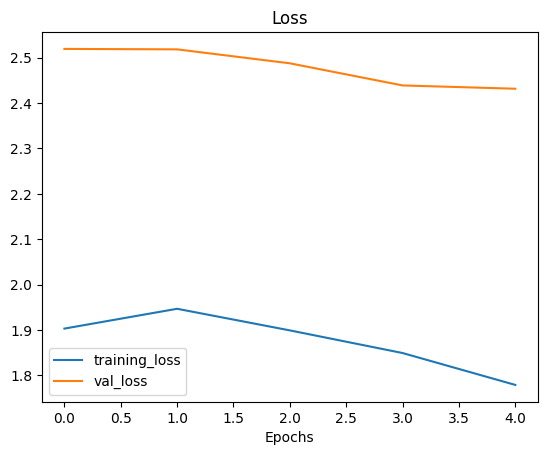

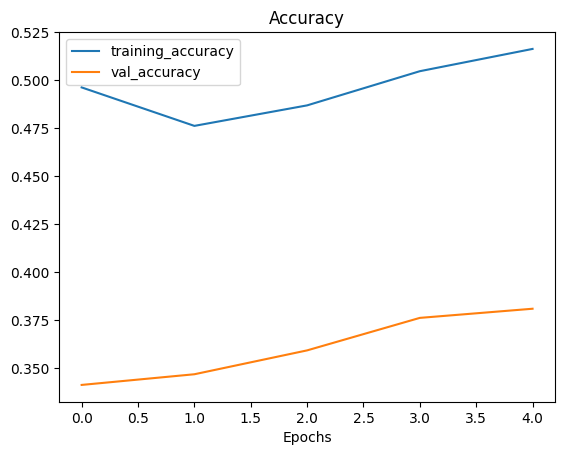

In [ ]:
plot_loss_curves(new_history)

In [ ]:
results = model.evaluate(test_data)
results

790/790 ━━━━━━━━━━━━━━━━━━━━ 55s 70ms/step - accuracy: 0.4427 - loss: 2.1532


# Let´s do fine tunning now

In [ ]:
base_model.trainable = True
fine_tune_at = -5

for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

In [ ]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=['accuracy']
)
model.load_weights("101_classes_10_percent_data_model_checkpoint.weights.h5")

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
history_with_fine_tunning = model.fit(
    train_10_percent_data,
    validation_data=test_data,
    validation_steps=int(0.15 * len(test_data)),
    callbacks = [checkpoint_cb],
    epochs=10,
    initial_epoch = history_model_all_classes.epoch[-1]
)

Epoch 5/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 31s 132ms/step - accuracy: 0.1979 - loss: 3.7374 - val_accuracy: 0.4590 - val_loss: 2.4130
Epoch 6/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 41s 130ms/step - accuracy: 0.2156 - loss: 3.6216 - val_accuracy: 0.4492 - val_loss: 2.4382
Epoch 7/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 40s 128ms/step - accuracy: 0.2365 - loss: 3.5092 - val_accuracy: 0.4486 - val_loss: 2.4362
Epoch 8/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 42s 131ms/step - accuracy: 0.2584 - loss: 3.4127 - val_accuracy: 0.4497 - val_loss: 2.4430
Epoch 9/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 41s 173ms/step - accuracy: 0.2776 - loss: 3.3123 - val_accuracy: 0.4460 - val_loss: 2.4515
Epoch 10/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 70s 125ms/step - accuracy: 0.2945 - loss: 3.2282 - val_accuracy: 0.4497 - val_loss: 2.4474


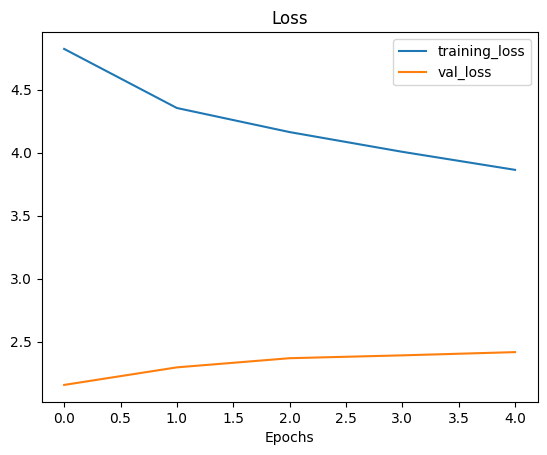

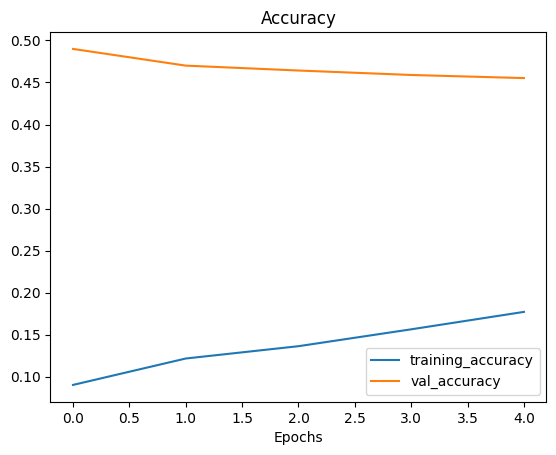

In [ ]:
plot_loss_curves(history_with_fine_tunning)